In [38]:
import pandas as pd
import numpy as np
import torch.nn.functional as F
from torch import nn
from Bio import SeqIO 
import torch

print ("imported")

imported


My plan is to separate the file into a 

In [ ]:
data_path = "./data/uniprotkb_taxonomy_id_1002366_2026_06_05.fasta"

sequences = [str(record.seq) for record in SeqIO.parse(data_path, "fasta")]

print("Number of sequences:", len(sequences))
print("First sequence:", sequences[0])
print("First sequence length:", len(sequences[0]))

Number of sequences: 2939
First sequence: MDDTKKRIHKYIEKHDLIRSDDKLLVAVSGGPDSFALLHFLWSAKLVPKEAIAVAHLNHHLRENAEKEQLAVQTFCEERDIPFFIEEVDVKKRAEKLQKGIEETARIVRYDFFEKVMAENNINKLVLAHHADDQIETILMRLVRGSSSIGWSGIQPKREVRGGYAIRPFLPITKAEIIEYANKHALPYEIDESNTSQEYTRNRYRTQLLPFLSKENPAVYEHFKRFSEETSEDFQFLEELASNLLKKNLIQNGKQSTLLLSDFKNEANPLQRRAIHLLLMYLYNDDGRVITVNHIYQIIQMIQSENPSSSIDLPKKLTVIRSYNELHFQFGERHAPPEFYHQLELNDRIELDNKASIRLKLKSSVVQTNGLNGMLLDAEDITLPLIVRNRVNGDRMTMKGQAGSKKLKDIFIDAKIPRQERDNLPVITDYTGKILWVPGVKKSAYDREFSRSKKQYIIRYTRNIGGNESMHNDIQKVLISEDELQEKIRELGRELTAEYEGRNPLVVGVLKGATPFMTDLLKRIDTYLEMDFMDVSSYGNGTVSSGEVKIIKDLNASVEGRDVLIIEDIIDSGRTLSYLVDLIKYRKAKSVKLVTLLDKPAGRNVAIEADYVGFVVPNEFVVGYGLDYAERYRNLPYIGILKPEIYSE
First sequence length: 648


In [40]:
sequences = [seq for seq in sequences if len(seq) < 1000]

In [41]:
print("Number of sequences:", len(sequences))


Number of sequences: 2901


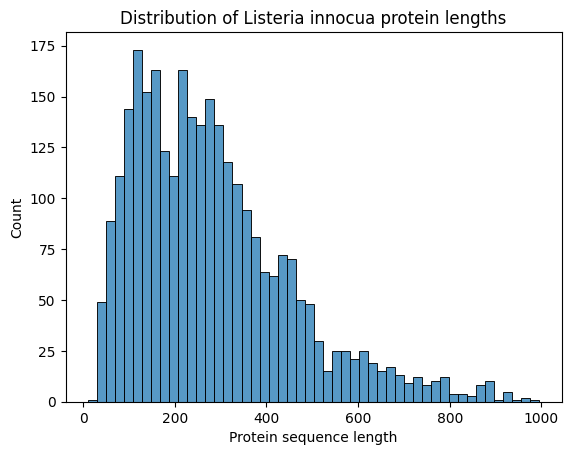

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

sequence_lengths = [len(seq) for seq in sequences]

sns.histplot(x=sequence_lengths, bins=50)

plt.xlabel("Protein sequence length")
plt.ylabel("Count")
plt.title("Distribution of Listeria innocua protein lengths")
plt.show()

In [43]:
AminoAcids = sorted(list(set("".join(sequences))) + ["-"] + ["X"])

print(len(AminoAcids))
print(AminoAcids)

22
['-', 'A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'X', 'Y']


In [44]:
aa_stoi = {s: i for i, s in enumerate(AminoAcids)}
aa_itos = {i: s for i, s in enumerate(AminoAcids)}

aa_encode = lambda s: F.one_hot(torch.tensor([aa_stoi[c] for c in s], dtype=torch.long), num_classes=len(AminoAcids)).float()
aa_decode = lambda x: "".join([aa_itos[i] for i in x.argmax(dim=-1).tolist()])

print(aa_encode("A"))
print(aa_decode(aa_encode("A")))

print(aa_encode("F"))

tensor([[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]])
A
tensor([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]])


In [45]:
X = torch.tensor(aa_encode(sequences[0]))
torch.set_printoptions(profile="default")

print(X)

tensor([[0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 0., 0., 1.],
        [0., 0., 0.,  ..., 0., 0., 0.],
        [0., 0., 0.,  ..., 0., 0., 0.]])


/var/folders/6x/zysy2by149j192lr_4fwtb680000gn/T/ipykernel_8387/3600627889.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(aa_encode(sequences[0]))


In [ ]:
encoded_sequences = [aa_encode(seq) for seq in sequences]

print("Number of encoded proteins:", len(encoded_sequences))
print("First encoded protein shape:", encoded_sequences[0].shape)

Number of encoded proteins: 2901
First encoded protein shape: torch.Size([648, 22])


In [ ]:
def one_hot_encode_sequence(seq):
    